In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Import sklearn library to perform L1, L2 & LR
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Import sklearn library to evaluate model using MAE, MSE & MAPE
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, max_error, r2_score

pd.options.mode.chained_assignment = None # Disable warning from pandas library
# pd.options.mode.chained_assignment = 'warn' # enable warning from pandas library

In [2]:
dataDF = pd.read_csv('SNRE_Data_w_Dummy_for_SPSS.csv') 

#change the denomination of some variables e.g. Population, GDP, Land Supply
dataDF['Total Population'] = dataDF['Total Population']/10000 
dataDF['Real GDP (in $Sm)'] = dataDF['Real GDP (in $Sm)']/10000 
dataDF['Total Multiple-User Factory Space (m2)'] = dataDF['Total Multiple-User Factory Space (m2)']/10000 
dataDF.rename(columns={"Total Population": "Total Population (in 10,000)", 
                       "Real GDP (in $Sm)": "Real GDP (in $S10,000m)",
                       "Total Multiple-User Factory Space (m2)": "Total Multiple-User Factory Space (10,000m2)"},
              inplace = True)

# Separate Input variables (x) and target variable (y)
# x = dataDF.drop(['Price','Unit Price ($ psf)', 'Location', 'Planning Area', 'Postal District','Postal Sector', 
#                  'Quarter', 'Month', 'Year','Contract Date', 'Project Name', 'Street Name','Area (sqft)','Floor Level',
#                  'First Floor','Type of Sale', 'New Sale','Central Region','Region','Rental Index',
#                  'latitude','longitude'], axis=1) #this is my dataframe of variables /w self-encoding dummy variables

x = dataDF.drop(['Unit Price ($ psf)','Floor Level','First Floor','Type of Sale', 'New Sale',
                 'Central Region','Region'], axis=1)

y = dataDF['Unit Price ($ psf)']

display(dataDF.info())
display(x.info())
display(y.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9297 entries, 0 to 9296
Data columns (total 24 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Floor Level                                   9297 non-null   object 
 1   First Floor                                   9297 non-null   int64  
 2   Non-First Floor                               9297 non-null   int64  
 3   Type of Sale                                  9297 non-null   object 
 4   New Sale                                      9297 non-null   int64  
 5   Resale                                        9297 non-null   int64  
 6   Subsale                                       9297 non-null   int64  
 7   Region                                        9297 non-null   object 
 8   Central Region                                9297 non-null   int64  
 9   East Region                                   9297 non-null   i

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9297 entries, 0 to 9296
Data columns (total 17 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Non-First Floor                               9297 non-null   int64  
 1   Resale                                        9297 non-null   int64  
 2   Subsale                                       9297 non-null   int64  
 3   East Region                                   9297 non-null   int64  
 4   North Region                                  9297 non-null   int64  
 5   North-East Region                             9297 non-null   int64  
 6   West Region                                   9297 non-null   int64  
 7   Remaining Tenure (Years)                      9297 non-null   int64  
 8   Total Population (in 10,000)                  9297 non-null   float64
 9   SORA (%)                                      9297 non-null   f

None

<class 'pandas.core.series.Series'>
RangeIndex: 9297 entries, 0 to 9296
Series name: Unit Price ($ psf)
Non-Null Count  Dtype  
--------------  -----  
9297 non-null   float64
dtypes: float64(1)
memory usage: 72.8 KB


None

Post Transformation Examination
------------------------------------------------
- Train/Test split - https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html#sklearn.model_selection.train_test_split
    - 0.8/0.2, 0.70/0.3, 0.9/0.1

In [3]:
# Split the dataset into the training and testing set.
input_train, input_test, target_train, target_test = train_test_split(x, y, 
                                                                      test_size = 0.2,
                                                                      random_state = 42,
                                                                      shuffle = True) 

display(input_train.head(3))

,Non-First Floor,Resale,Subsale,East Region,North Region,North-East Region,West Region,Remaining Tenure (Years),"Total Population (in 10,000)",SORA (%),"Real GDP (in $S10,000m)","Total Multiple-User Factory Space (10,000m2)",US Dollar (Singapore Dollar Per US Dollar),TPI % Change,lagged psf,Rental Index % change,minDistToMRT
5125,1,1,0,1,0,0,0,50,568.5807,0.10,46.264793,163.4,1.38,2.8,549.58,-12.1,447.66
2907,1,1,0,0,1,0,0,40,570.3569,1.90,48.133521,171.1,1.36,-0.1,165.77,-6.1,1704.83
5349,1,1,0,1,0,0,0,50,568.5807,0.18,46.264793,165.1,1.38,2.8,386.38,-12.0,447.66


Linear Regression Model 
=========================
 URL - https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression
 
- Input Variable - input_train, input_test
- Target Variable - target_train, target_test

In [4]:
# Creates an LinearRegression Object
lrModel = LinearRegression()
# Trains an LR model based on my training data
lrModel.fit(input_train, target_train)

lrModel_coef = [(x, y) for x, y in zip(lrModel.feature_names_in_, lrModel.coef_.round(2))]
lrModel_coef.append(('Intercept', lrModel.intercept_.round(2)))
display(lrModel_coef)

# Do prediction with lrModel with input_test
lr_pred = lrModel.predict(input_test)
lr_score = lrModel.score(input_test, target_test) # R2 values - Goodness of Fit

# Compute Error metrics for Baseline LR Model
lrpred_mae = mean_absolute_error(target_test,lr_pred)
lrpred_mse = mean_squared_error(target_test,lr_pred)
lrpred_mape = mean_absolute_percentage_error(target_test,lr_pred)
lrpred_max = max_error(target_test,lr_pred)

print('Mae: {}'.format(lrpred_mae.round(2)))
print('Mse: {}'.format(lrpred_mse.round(2)))
print('Mape: {}'.format(lrpred_mape.round(2)))
print('Max: {}'.format(lrpred_max.round(2)))
print('R2 Score: {}'.format(lr_score.round(2)))

[('Non-First Floor', -50.62),
 ('Resale', -16.25),
 ('Subsale', 18.55),
 ('East Region', -40.5),
 ('North Region', -39.76),
 ('North-East Region', -12.61),
 ('West Region', -25.92),
 ('Remaining Tenure (Years)', 1.66),
 ('Total Population (in 10,000)', -0.18),
 ('SORA (%)', 1.57),
 ('Real GDP (in $S10,000m)', 0.44),
 ('Total Multiple-User Factory Space (10,000m2)', 0.05),
 ('US Dollar (Singapore Dollar Per US Dollar)', 57.55),
 ('TPI % Change', 0.43),
 ('lagged psf', 0.68),
 ('Rental Index % change', 0.4),
 ('minDistToMRT', -0.0),
 ('Intercept', 115.13)]

Mae: 46.09
Mse: 4150.57
Mape: 0.14
Max: 541.76
R2 Score: 0.76


Ridge Regression Model (L2) 
=================
URL - https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html#sklearn.linear_model.Ridge

- Input Variable - var_train, var_test
- Target Variable - target_train, target_test
- Need to tune the optimal value of hyperparameter, Alpha
    - https://scikit-learn.org/stable/modules/grid_search.html
    - RidgeCV()
- Need to perform normalisation?? - https://stackoverflow.com/questions/50747922/python-sklearn-ridge-regression-normalize
- Model Evaluation Metrics - https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics
    - MAE
    - MSE
    - MAPE

In [5]:
#Building the Ridge Regression model with Training Data
l2Model = Ridge(alpha = 58.3) 
l2Model.fit(input_train, target_train)

l2Model_coef = [(x, y) for x, y in zip(l2Model.feature_names_in_, l2Model.coef_.round(3))]
l2Model_coef.append(('Intercept', l2Model.intercept_.round(2)))
display(l2Model_coef)

# Do prediction with l2Model with var_test (Testing set)
l2_pred = l2Model.predict(input_test)
l2_score = l2Model.score(input_test, target_test)

# Compute Error metrics for Ridge Regression Model
l2pred_mae = mean_absolute_error(target_test,l2_pred)
l2pred_mse = mean_squared_error(target_test,l2_pred)
l2pred_mape = mean_absolute_percentage_error(target_test,l2_pred)
l2pred_max = max_error(target_test,l2_pred)

print('Mae: {}'.format(l2pred_mae.round(2)))
print('Mse: {}'.format(l2pred_mse.round(2)))
print('Mape: {}'.format(l2pred_mape.round(2)))
print('Max: {}'.format(l2pred_max.round(2)))
print('R2 Score: {}'.format(l2_score.round(2)))

[('Non-First Floor', -46.263),
 ('Resale', -14.915),
 ('Subsale', 11.845),
 ('East Region', -32.284),
 ('North Region', -33.14),
 ('North-East Region', -6.343),
 ('West Region', -18.602),
 ('Remaining Tenure (Years)', 1.638),
 ('Total Population (in 10,000)', -0.036),
 ('SORA (%)', 0.702),
 ('Real GDP (in $S10,000m)', 0.686),
 ('Total Multiple-User Factory Space (10,000m2)', 0.033),
 ('US Dollar (Singapore Dollar Per US Dollar)', 3.513),
 ('TPI % Change', 0.352),
 ('lagged psf', 0.687),
 ('Rental Index % change', 0.475),
 ('minDistToMRT', -0.003),
 ('Intercept', 87.73)]

Mae: 45.92
Mse: 4128.17
Mape: 0.14
Max: 540.93
R2 Score: 0.76


Lasso Regression Model (L1) 
====================
URL - https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html#sklearn.linear_model.Lasso

- Input Variable - var_train, var_test
- Target Variable - target_train, target_test
- Need to tune the optimal value of hyperparameter, Alpha
    - https://scikit-learn.org/stable/modules/grid_search.html
    - https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html#sklearn.linear_model.LassoCV
- Need to perform normalisation?? - https://stackoverflow.com/questions/50747922/python-sklearn-ridge-regression-normalize
- Model Evaluation Metrics - https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics
    - MAE
    - MSE
    - MAPE

In [6]:
#Building the LASSO Regression model with Training Data
l1Model = Lasso(alpha = 0.06) 
l1Model.fit(input_train, target_train)

l1Model_coef = [(x, y) for x, y in zip(l1Model.feature_names_in_, l1Model.coef_.round(2))]
l1Model_coef.append(('Intercept', l1Model.intercept_.round(2)))
display(l1Model_coef)

# Do prediction with l1Model with var_test
l1_pred = l1Model.predict(input_test)
l1_score = l1Model.score(input_test, target_test)

# Compute Error metrics for Lasso Regression Model
l1pred_mae = mean_absolute_error(target_test,l1_pred)
l1pred_mse = mean_squared_error(target_test,l1_pred)
l1pred_mape = mean_absolute_percentage_error(target_test,l1_pred)
l1pred_max = max_error(target_test,l1_pred)

print('Mae: {}'.format(l1pred_mae.round(2)))
print('Mse: {}'.format(l1pred_mse.round(2)))
print('Mape: {}'.format(l1pred_mape.round(2)))
print('Max: {}'.format(l1pred_max.round(2)))
print('R2 Score: {}'.format(l1_score.round(2)))

[('Non-First Floor', -49.85),
 ('Resale', -15.75),
 ('Subsale', 14.22),
 ('East Region', -37.93),
 ('North Region', -37.55),
 ('North-East Region', -9.37),
 ('West Region', -23.09),
 ('Remaining Tenure (Years)', 1.65),
 ('Total Population (in 10,000)', -0.02),
 ('SORA (%)', 0.47),
 ('Real GDP (in $S10,000m)', 0.67),
 ('Total Multiple-User Factory Space (10,000m2)', 0.03),
 ('US Dollar (Singapore Dollar Per US Dollar)', 0.0),
 ('TPI % Change', 0.37),
 ('lagged psf', 0.68),
 ('Rental Index % change', 0.46),
 ('minDistToMRT', -0.0),
 ('Intercept', 91.8)]

Mae: 46.02
Mse: 4139.41
Mape: 0.14
Max: 541.38
R2 Score: 0.76


In [7]:
scoreDF = pd.DataFrame(data={'Testing_Model':['Linear Regression','Ridge Regression Model(L2)','Lasso Regression Model(L1)'],
                             'MAX ($)':[lrpred_max,l2pred_max,l1pred_max],
                             'MAE ($)':[lrpred_mae,l2pred_mae,l1pred_mae],
                             'MSE ($)':[lrpred_mse,l2pred_mse,l1pred_mse],
                             'MAPE (%)':[lrpred_mape,l2pred_mape,l1pred_mape],
                             'R2':[lr_score,l2_score,l1_score],
                             'Alpha':[np.nan,58.3,0.06]})

pd.options.display.float_format = '{:.2f}'.format
display(scoreDF)


print("Linear Regression Model:\nMAE: {}\nMSE: {}\nMAPE:{}\nR2: {}".format(lrpred_mae,lrpred_mse, lrpred_mape, lr_score))
print("")

print("Ridge Regression Model(L2):\nMAE: {}\nMSE: {}\nMAPE:{}\nR2: {}".format(l2pred_mae,l2pred_mse, l2pred_mape, l2_score))
print("")

print("Lasso Regression Model(L1):\nMAE: {}\nMSE: {}\nMAPE:{}\nR2: {}".format(l1pred_mae,l1pred_mse, l1pred_mape, l1_score))



,Testing_Model,MAX ($),MAE ($),MSE ($),MAPE (%),R2,Alpha
0,Linear Regression,541.76,46.09,4150.57,0.14,0.76,NaN
1,Ridge Regression Model(L2),540.93,45.92,4128.17,0.14,0.76,57.90
2,Lasso Regression Model(L1),541.38,46.02,4139.41,0.14,0.76,0.06


Linear Regression Model:
MAE: 46.09232620878852
MSE: 4150.571752032076
MAPE:0.13947797840679213
R2: 0.7633843588006164

Ridge Regression Model(L2):
MAE: 45.92234010085378
MSE: 4128.165251209557
MAPE:0.13852482949802697
R2: 0.7646617077722513

Lasso Regression Model(L1):
MAE: 46.022747880184866
MSE: 4139.40891009238
MAPE:0.1391567031099406
R2: 0.7640207296817789


Hyperparameter Tunning - Penalty Term, alpha
=======================
https://ai-ml-analytics.com/Jupyter_notebook/Blog%20-%2020%20-%20Hyperparameter%20tuning%20using%20Ridge%20and%20Lasso%20Regression.html

Remember when alpha = 0, Ridge/Lasso regression is the same as your OLS model

https://stackoverflow.com/questions/57376860/how-to-run-gridsearchcv-with-ridge-regression-in-sklearn

https://www.youtube.com/watch?v=TvB_3jVIHhg

Why MAE is negative - https://stackoverflow.com/questions/62125674/why-is-negative-mse-or-mas-scoring-parameter-like-neg-mean-absolute-error-in

In [8]:
from sklearn.model_selection import GridSearchCV

# Setup the Ridge Regression Model - ridgeModel
ridgeModel = Ridge()

# set the search space - hyperParameters
hyperParameters = {'alpha':np.arange(55,60.1,0.1)}

# Create the GridSearchCV object
l2GS = GridSearchCV(estimator = ridgeModel,  #This is the model i trying to optimise
                    param_grid = hyperParameters, # What is the Hyperparameter am I trying to finetune.
                    scoring = ['neg_mean_absolute_error', 'neg_mean_squared_error',
                               'neg_mean_absolute_percentage_error', 'r2'], # what is the metric I'm going to use.
                    cv = 10,
                    refit = 'neg_mean_absolute_error',
                    verbose = 0)

print(len(hyperParameters['alpha']))


52


In [9]:
l2GS.fit(input_train, target_train)

GridSearchCV(cv=10, estimator=Ridge(),
             param_grid={'alpha': array([55. , 55.1, 55.2, 55.3, 55.4, 55.5, 55.6, 55.7, 55.8, 55.9, 56. ,
       56.1, 56.2, 56.3, 56.4, 56.5, 56.6, 56.7, 56.8, 56.9, 57. , 57.1,
       57.2, 57.3, 57.4, 57.5, 57.6, 57.7, 57.8, 57.9, 58. , 58.1, 58.2,
       58.3, 58.4, 58.5, 58.6, 58.7, 58.8, 58.9, 59. , 59.1, 59.2, 59.3,
       59.4, 59.5, 59.6, 59.7, 59.8, 59.9, 60. , 60.1])},
             refit='neg_mean_absolute_error',
             scoring=['neg_mean_absolute_error', 'neg_mean_squared_error',
                      'neg_mean_absolute_percentage_error', 'r2'])

In [10]:
print(l2GS.best_params_)
print(l2GS.best_score_)
print(l2GS.best_estimator_)

{'alpha': 58.30000000000005}
-44.883751514850005
Ridge(alpha=58.30000000000005)


,param_alpha,mean_test_neg_mean_absolute_error
0,55.00,44.88
1,55.10,44.88
2,55.20,44.88
3,55.30,44.88
4,55.40,44.88
5,55.50,44.88
6,55.60,44.88
7,55.70,44.88
8,55.80,44.88
9,55.90,44.88


<Axes: xlabel='param_alpha', ylabel='mean_test_neg_mean_absolute_error'>

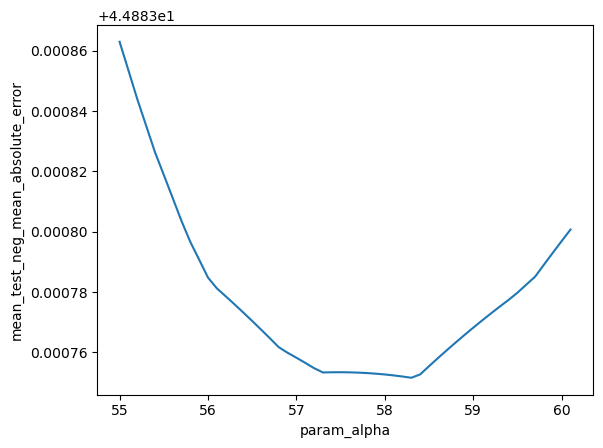

In [11]:
l2_df = pd.DataFrame(l2GS.cv_results_)
l2error_df = l2_df[['param_alpha',
                    'mean_test_neg_mean_absolute_error']]
#df.to_csv('results.csv')

display(l2error_df.abs())

sns.lineplot(data=l2error_df.abs(), x="param_alpha", y="mean_test_neg_mean_absolute_error")

In [12]:
# Setup the Lasso Regression Model - ridgeModel
lassoModel = Lasso()

# set the search space - hyperParameters
hyperParameters = {'alpha':np.arange(0.01,0.11,0.01)}

# Create the GridSearchCV object
l1GS = GridSearchCV(estimator = lassoModel,  #This is the model i trying to optimise
                          param_grid = hyperParameters, # What is the Hyperparameter am I trying to finetune.
                          scoring = ['neg_mean_absolute_error', 'neg_mean_squared_error', 
                                     'neg_mean_absolute_percentage_error', 'r2'], # what is the metric I'm going to use.
                          cv = 10,
                          refit = 'neg_mean_absolute_error',
                          verbose = 0)

In [13]:
l1GS.fit(input_train, target_train)

GridSearchCV(cv=10, estimator=Lasso(),
             param_grid={'alpha': array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ])},
             refit='neg_mean_absolute_error',
             scoring=['neg_mean_absolute_error', 'neg_mean_squared_error',
                      'neg_mean_absolute_percentage_error', 'r2'])

In [14]:
print(l1GS.best_params_)
print(l1GS.best_score_)
print(l1GS.best_estimator_)

{'alpha': 0.060000000000000005}
-44.92375985958317
Lasso(alpha=0.060000000000000005)


,param_alpha,mean_test_neg_mean_absolute_error
0,0.01,44.93
1,0.02,44.93
2,0.03,44.93
3,0.04,44.92
4,0.05,44.92
5,0.06,44.92
6,0.07,44.92
7,0.08,44.92
8,0.09,44.93
9,0.10,44.93


<Axes: xlabel='param_alpha', ylabel='mean_test_neg_mean_absolute_error'>

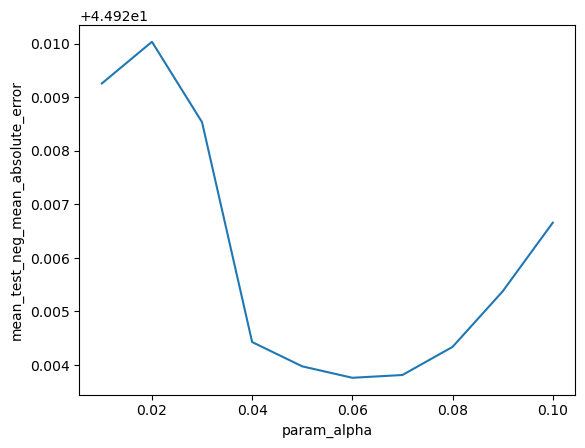

In [15]:
l1_df = pd.DataFrame(l1GS.cv_results_)
l1error_df = l1_df[['param_alpha',
                    'mean_test_neg_mean_absolute_error']]
#df.to_csv('results.csv')

display(l1error_df.abs())

sns.lineplot(data=l1error_df.abs(), x="param_alpha", y="mean_test_neg_mean_absolute_error")